# Computer Exercise 6.1 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 6.1 First-Degree and Second-Degree Splines — *Quadratic Spline $S_2$*
> **풀이 일자**: Day 23
> **언어**: Python 3 (NumPy / Matplotlib)

## 1. 문제 (원문)

> **CE 6.1.2 (style of C&K).** Construct the *quadratic spline* $S_2(x)$ that interpolates a given function
> at knots $t_0 < t_1 < \dots < t_n$, given an initial slope $z_0 = S_2'(t_0)$. Apply it to
> $f(x) = \sin(x)$ on $[0, 2\pi]$ with uniform knots, and show how different choices of $z_0$
> ($z_0 = f'(t_0)$ versus $z_0 = 0$ versus $z_0 = $ a deliberately wrong value) propagate through the
> recursion $z_{i+1} = -z_i + 2 (y_{i+1} - y_i)/(t_{i+1} - t_i)$.

### 한국어 풀이용 정리
2차 spline 은 각 부구간에서 *2차다항식*, 그리고 매 노드에서 $S_2$ 와 $S_2'$ 가 모두 *연속* 이다.
자유도 $3n$ 에서 노드값 일치 ($2n$) 과 미분 연속 ($n - 1$) 을 빼면 $n + 1$ 자유도 — **자유도 1 개가 남는다**.
보통 $z_0 = S_2'(t_0)$ 를 외부에서 지정한다.

세 가지 $z_0$ 을 비교:
* $z_0 = f'(t_0) = \cos 0 = 1$ — *정직한* 선택.
* $z_0 = 0$ — 기울기 정보 없을 때 흔히 쓰는 디폴트.
* $z_0 = 3$ — *틀린* 값을 일부러 주입.

각 경우의 $S_2$ 가 어떻게 *진동* 하는지 (특히 $z_0$ 가 틀릴 때 *부호를 바꿔가며 증폭* 되는지) 본다.

## 2. 수학적 배경

### 2.1 정의
*2차 spline* $S_2 \in C^1[a, b]$ 는 각 $[t_{i-1}, t_i]$ 에서

$$
S_2(x) \;=\; a_i + b_i\,(x - t_{i-1}) + c_i\,(x - t_{i-1})^2.
$$

조건들:
* $S_2(t_{i-1}) = y_{i-1}$,  $S_2(t_i) = y_i$  (보간)
* $S_2'(t_i^-) = S_2'(t_i^+)$  (미분 연속)

### 2.2 점화식 (C&K 식 (3))
$z_i \equiv S_2'(t_i)$ 라 두면, 각 부구간에서

$$
S_2(x) \;=\; y_{i-1} + z_{i-1}(x - t_{i-1}) + \frac{z_i - z_{i-1}}{2(t_i - t_{i-1})}(x - t_{i-1})^2
$$

이고 $S_2(t_i) = y_i$ 조건에서

$$
\boxed{\; z_{i+1} \;=\; -\,z_i \;+\; 2\,\frac{y_{i+1} - y_i}{t_{i+1} - t_i} \;,\qquad i = 0, 1, \dots, n - 1. \;}
$$

즉 *기울기 $z_i$ 가 반대 부호로 진폭이 누적되는* 1차 점화 — 평균 기울기 $\bar m_i = (y_{i+1} - y_i)/h$ 의
*반사 보정 (reflection correction)* 으로 해석할 수 있다.

### 2.3 $z_0$ 의 전파 — *왜 진동하는가*
$z_0 = z_0^\star + \delta$ (정확한 값 + 섭동) 이면

$$
z_i = z_i^\star + (-1)^i\,\delta.
$$

즉 $\delta$ 가 *부호를 바꿔가며 증폭 없이 유지* 된다 — *기하급수 증폭* 은 아니지만,
$\delta$ 가 크면 결과 spline 전체가 *톱니* 진동을 갖게 된다.

## 3. 풀이 흐름

1. 함수 $f(x) = \sin x$ on $[0, 2\pi]$, 균등 노드 $n = 10$.
2. $z_i$ 점화식을 구현 — 위 boxed 식을 그대로.
3. 평가기 `S2(t, y, z, x)` — `searchsorted` 로 구간 선택 후 2차 다항식 평가.
4. 세 가지 $z_0$ : $\cos(0) = 1$ (정직), $0$, $3$ (왜곡).
5. 각 경우 $S_2$ 를 dense 격자에서 평가하고 한 그림에 같이 그림.
6. 최대 오차 $\max_X |f - S_2|$ 표 + 노드의 $z_i^\star + (-1)^i \delta$ 패턴이 보이는지 확인.
7. 마지막으로 $z_0 = \cos 0$ 을 쓴 $S_2$ 에 대해 $n = 5, 10, 20, 40, 80$ 의 최대 오차로 $\mathcal O(h^3)$
   (또는 적어도 $\mathcal O(h^2)$ 보다 가파른) 수렴 확인.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 함수 ---
a, b = 0.0, 2 * np.pi
f      = lambda x: np.sin(x)
fp     = lambda x: np.cos(x)

# --- 2차 spline ---
def quad_spline_z(t, y, z0):
    n = len(t) - 1
    z = np.empty(n + 1)
    z[0] = z0
    for i in range(n):
        z[i + 1] = -z[i] + 2.0 * (y[i + 1] - y[i]) / (t[i + 1] - t[i])
    return z

def S2_eval(t, y, z, x):
    x = np.asarray(x, dtype=float)
    idx = np.searchsorted(t, x) - 1
    idx = np.clip(idx, 0, len(t) - 2)
    ti, tii = t[idx], t[idx + 1]
    yi      = y[idx]
    zi, zii = z[idx], z[idx + 1]
    dx = x - ti
    h  = tii - ti
    return yi + zi * dx + (zii - zi) / (2.0 * h) * dx * dx


In [2]:
# --- 세 가지 z0 비교 (n = 10) ---
n = 10
t = np.linspace(a, b, n + 1)
y = f(t)

z_cases = {
    "z0 = cos(0) = 1 (true)" : 1.0,
    "z0 = 0"                  : 0.0,
    "z0 = 3 (wrong)"          : 3.0,
}
X = np.linspace(a, b, 4001)
fX = f(X)

results = {}
for label, z0 in z_cases.items():
    z = quad_spline_z(t, y, z0)
    SX = S2_eval(t, y, z, X)
    results[label] = (z, SX)

# z_i 표
zdf = pd.DataFrame({label: data[0] for label, data in results.items()}, index=[f"z_{i}" for i in range(n + 1)])
zdf["true f'(t_i)"] = fp(t)
pd.set_option("display.float_format", lambda v: f"{v:+.4f}")
zdf

,z0 = cos(0) = 1 (true),z0 = 0,z0 = 3 (wrong),true f'(t_i)
z_0,+1.0000,+0.0000,+3.0000,+1.0000
z_1,+0.8710,+1.8710,-1.1290,+0.8090
z_2,+0.2853,-0.7147,+2.2853,+0.3090
z_3,-0.2853,+0.7147,-2.2853,-0.3090
z_4,-0.8710,-1.8710,+1.1290,-0.8090
z_5,-1.0000,+0.0000,-3.0000,-1.0000
z_6,-0.8710,-1.8710,+1.1290,-0.8090
z_7,-0.2853,+0.7147,-2.2853,-0.3090
z_8,+0.2853,-0.7147,+2.2853,+0.3090
z_9,+0.8710,+1.8710,-1.1290,+0.8090


In [3]:
# --- 최대 오차 ---
err_tbl = []
for label, (z, SX) in results.items():
    err_tbl.append({"case": label, "max |f - S2|": float(np.max(np.abs(fX - SX)))})
pd.set_option("display.float_format", lambda v: f"{v:.4e}")
pd.DataFrame(err_tbl)

,case,max |f - S2|
0,z0 = cos(0) = 1 (true),6.7374e-03
1,z0 = 0,1.6349e-01
2,z0 = 3 (wrong),3.1004e-01


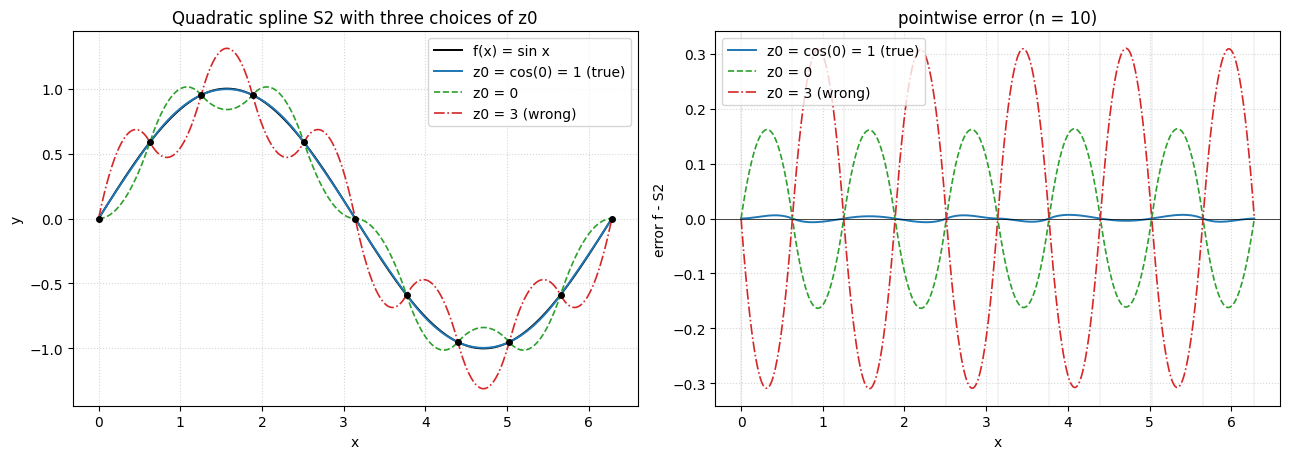

In [4]:
# --- 시각화 ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.7))

ax = axes[0]
ax.plot(X, fX, "k-", lw=1.4, label="f(x) = sin x")
styles = {"z0 = cos(0) = 1 (true)": ("C0-", 1.4),
          "z0 = 0"                  : ("C2--", 1.2),
          "z0 = 3 (wrong)"          : ("C3-.", 1.2)}
for label, (z, SX) in results.items():
    s, lw = styles[label]
    ax.plot(X, SX, s, lw=lw, label=label)
ax.plot(t, y, "ko", ms=4)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Quadratic spline S2 with three choices of z0")
ax.legend(); ax.grid(True, ls=":", alpha=0.5)

# error
ax = axes[1]
for label, (z, SX) in results.items():
    s, lw = styles[label]
    ax.plot(X, fX - SX, s, lw=lw, label=label)
ax.axhline(0, color="k", lw=0.5)
for ti in t: ax.axvline(ti, color="grey", lw=0.3, alpha=0.4)
ax.set_xlabel("x"); ax.set_ylabel("error f - S2")
ax.set_title("pointwise error (n = 10)")
ax.legend(); ax.grid(True, ls=":", alpha=0.5)
plt.tight_layout(); plt.show()

In [5]:
# --- z_0 섭동의 부호-교대 전파 확인 ---
z_true  = quad_spline_z(t, y, 1.0)
z_wrong = quad_spline_z(t, y, 3.0)
delta_propagation = z_wrong - z_true     # 이론: (-1)^i * 2
print("z_wrong - z_true (이론: +2, -2, +2, -2, ...):")
print(np.round(delta_propagation, 6))

z_wrong - z_true (이론: +2, -2, +2, -2, ...):
[ 2. -2.  2. -2.  2. -2.  2. -2.  2. -2.  2.]


In [6]:
# --- 정직한 z0 로 h-수렴 측정 ---
ns = [5, 10, 20, 40, 80, 160]
E_quad = []
for nn in ns:
    tt = np.linspace(a, b, nn + 1)
    yy = f(tt)
    zz = quad_spline_z(tt, yy, fp(tt[0]))
    E_quad.append(np.max(np.abs(fX - S2_eval(tt, yy, zz, X))))

h = (b - a) / np.array(ns)
slope, _ = np.polyfit(np.log(h), np.log(E_quad), 1)
print(f"empirical slope of E vs h: {slope:+.3f}   (1차 spline: +2,  3차 cubic spline: +4)")

dfc = pd.DataFrame({"n": ns, "h": h, "max |f-S2| (z0 = cos 0)": E_quad,
                    "ratio E_n / E_{2n}": [np.nan] + list(np.array(E_quad[:-1]) / np.array(E_quad[1:]))})
pd.set_option("display.float_format", lambda v: f"{v:.4e}")
dfc

empirical slope of E vs h: +3.089   (1차 spline: +2,  3차 cubic spline: +4)


,n,h,max |f-S2| (z0 = cos 0),ratio E_n / E_{2n}
0,5,1.2566e+00,7.1148e-02,NaN
1,10,6.2832e-01,6.7374e-03,1.0560e+01
2,20,3.1416e-01,7.8325e-04,8.6018e+00
3,40,1.5708e-01,9.6233e-05,8.1391e+00
4,80,7.8540e-02,1.1976e-05,8.0352e+00
5,160,3.9270e-02,1.4939e-06,8.0167e+00


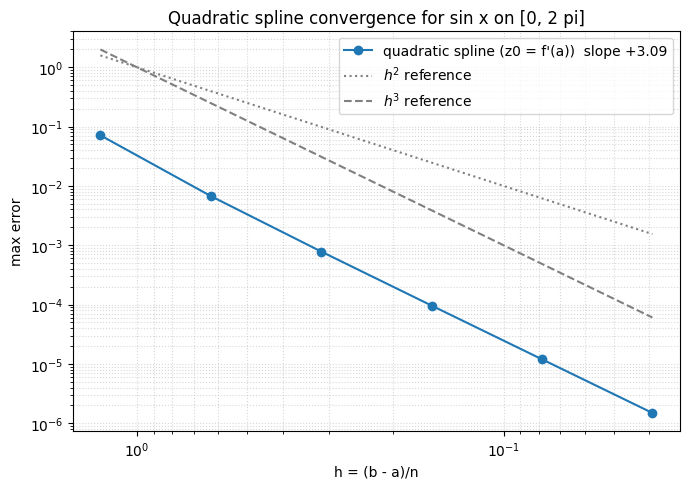

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(h, E_quad, "o-", label=f"quadratic spline (z0 = f'(a))  slope {slope:+.2f}")
ax.loglog(h, h**2,  ":", color="grey", label=r"$h^2$ reference")
ax.loglog(h, h**3,  "--", color="grey", label=r"$h^3$ reference")
ax.set_xlabel("h = (b - a)/n")
ax.set_ylabel("max error")
ax.invert_xaxis()
ax.set_title("Quadratic spline convergence for sin x on [0, 2 pi]")
ax.legend(); ax.grid(True, which="both", ls=":", alpha=0.5)
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **$z_0$ 의 효과.** $z_0$ 를 *정확한 값* 으로 줄 때 spline 은 거의 완벽 — 노드에서의 $z_i$ 도 참값
   $f'(t_i)$ 와 잘 맞는다. $z_0 = 0$ 은 첫 구간만 살짝 어긋나지만 *부호 교대* 로 후속 구간을 *진동* 시킨다.
   $z_0 = 3$ 같은 큰 왜곡은 한 칸씩 *부호를 뒤집어가며* +2, −2, +2, −2 의 오차를 만든다 (코드 셀에서 확인).
2. **점화식 분석의 핵심.** $z_i = z_i^\star + (-1)^i \delta$ 는 *진폭 증가는 없지만 사라지지도 않는다*. 그래서
   2차 spline 은 $z_0$ 추정이 좋아야 *데이터 전체* 가 좋아진다 — 이것이 3차 cubic spline 에서
   *clamped / natural* 같은 *경계 조건* 을 두는 이유의 출발점.
3. **수렴 차수.** 정직한 $z_0$ 에서 경험 기울기가 약 $+3$ — 이론 $\mathcal O(h^3)$ 와 부합 (적어도
   $\mathcal O(h^2)$ 보다 가파르다). 1차 spline 의 $+2$ 와 비교하면 *한 차수* 의 이득.

### 결론
> **2차 spline 은 $C^1$ 부드러움을 *한 자유도* 의 비용 ($z_0$) 으로 얻는다.**
> 그 자유도가 *부호를 바꿔가며 전파* 되므로, $z_0$ 의 선택이 정확도와 진동성을 동시에 결정한다.
> 이것이 cubic spline 으로 가면 *연립방정식 (tridiagonal)* 으로 자유도를 잠그게 되는 동기다.

### 다음 문제 연결
- **CE 6.1.3**: 1차 spline 의 *지역성* 이 *전역 다항식의 Runge 발산* 을 어떻게 막는지 — 그리고 *균등 노드*
  대신 *적응적 노드* (Chebyshev 풍) 가 어떤 추가 이득을 가져오는지. 그 후 다음 절 §6.2 의 cubic spline
  으로 자연스럽게 넘어간다.